# Librerias

In [1]:
# Manejo de datos
import pandas as pd
import numpy as np


# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Optuna
import optuna

# Preprocesamiento de datos
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline

# Copy
import copy

# Manejo de desbalance de clases
from imblearn.over_sampling import SMOTE


# Construcción de la Red Neuronal (PyTorch)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Métricas de evaluación
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, ConfusionMatrixDisplay,fbeta_score)

# Configuración visual para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Verificar si hay GPU disponible para PyTorch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Librerías importadas. PyTorch utilizará el dispositivo: {device}")

Librerías importadas. PyTorch utilizará el dispositivo: cuda


In [2]:
# Definir una semilla global
SEED = 20
# Configurar NumPy
np.random.seed(SEED)
# Configurar PyTorch (CPU y GPU)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED) # Para multi-GPU
    # Garantizar algoritmos deterministas (puede impactar ligeramente el rendimiento)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# EDA

In [3]:
import os
import zipfile

csv_path = "healthcare-dataset-stroke-data.csv"

if not os.path.exists(csv_path):
    zip_path = "archive.zip"
    !gdown 1CZOPvXzpA48GC2WVsmA5hZvyQugDQ6sQ -O {zip_path}
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall("Problema1")
    os.remove(zip_path)
else:
    print("Dataset ya existe, omitiendo descarga.")


Dataset ya existe, omitiendo descarga.


In [4]:
dataset = pd.read_csv("healthcare-dataset-stroke-data.csv")

In [5]:
data = dataset.copy()

### Exploracion de los tipos de datos y que contienen cada variable.

In [6]:
data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


In [8]:
data.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [9]:
data = data.drop(columns=["id"]) 

Cantidad de datos en categoricas

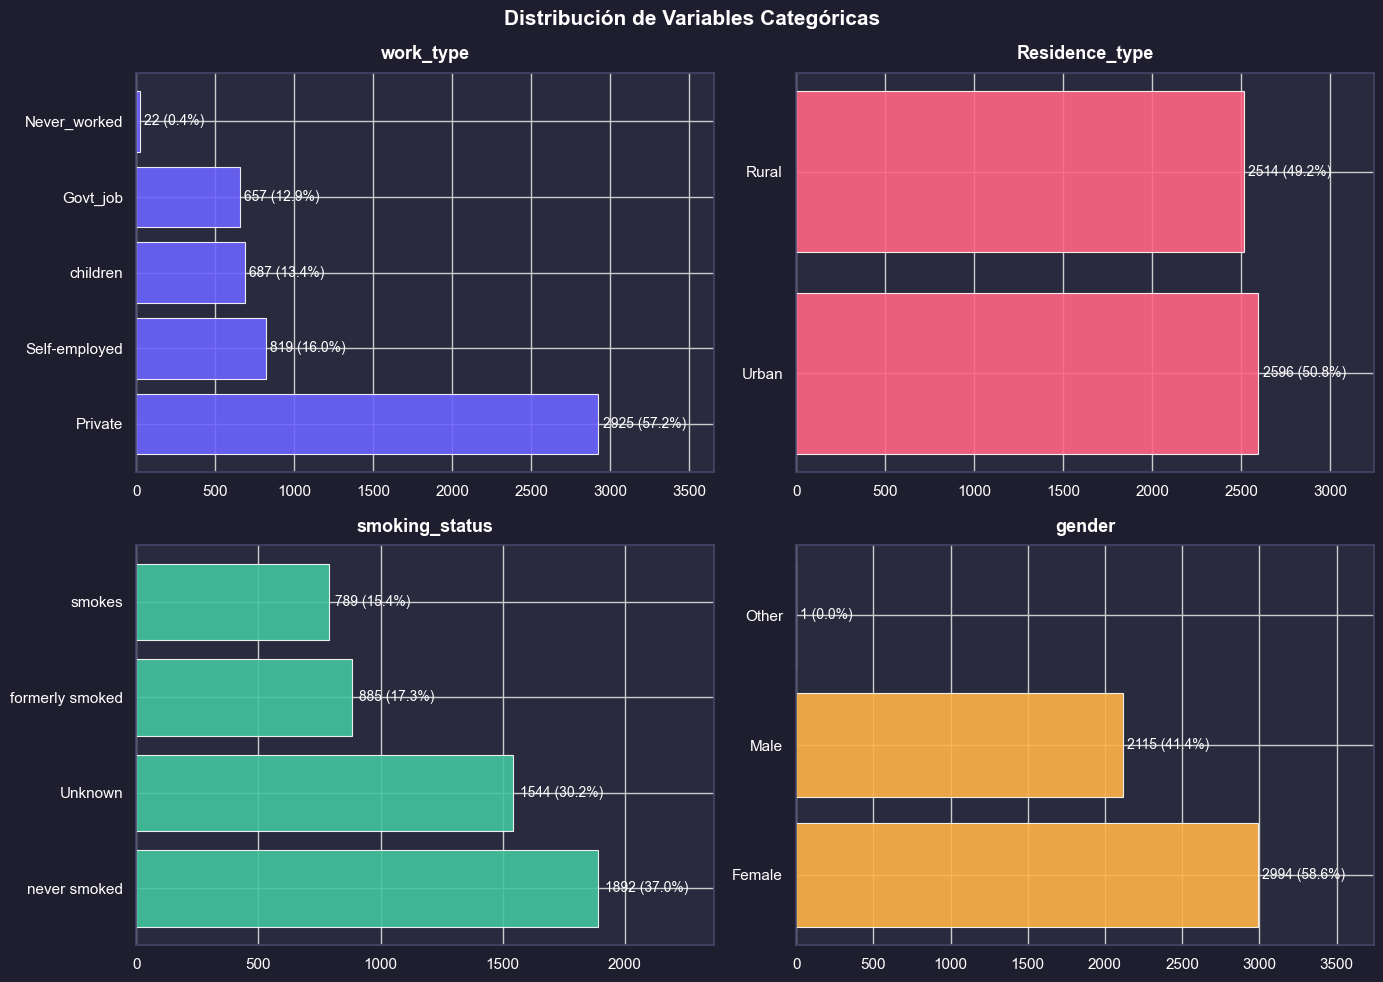

In [10]:
# Cargar original para graficar (o tener data_raw guardado antes del OHE)
cols = ["work_type", "Residence_type", "smoking_status", "gender"]
palette = ["#6C63FF", "#FF6584", "#43C59E", "#FFB347"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor("#1E1E2E")
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    ax.set_facecolor("#2A2A3E")
    
    counts = data[col].value_counts()
    total = counts.sum()
    color = palette[i]
    
    bars = ax.barh(counts.index, counts.values, color=color, edgecolor="white", linewidth=0.8, alpha=0.9)
    
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_width() + total * 0.005, bar.get_y() + bar.get_height() / 2,
                f"{val} ({val/total*100:.1f}%)", va="center", color="white", fontsize=10)
    
    ax.set_title(col, color="white", fontsize=13, fontweight="bold", pad=10)
    ax.tick_params(colors="white")
    ax.set_xlim(0, counts.max() * 1.25)
    for spine in ax.spines.values():
        spine.set_edgecolor("#444466")

plt.suptitle("Distribución de Variables Categóricas", color="white", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


Se extrae la siguentes concluciones del grafico anterior:

*   **Prevalencia Laboral (`work_type`):** El sector **"Private"** domina la muestra con un **57.2%**, lo que indica que la mayoría de los individuos pertenecen a la fuerza laboral activa privada. Es relevante notar que las categorías "Self-employed", "children" y "Govt_job" tienen una representación equilibrada entre sí, mientras que "Never_worked" es marginal (0.4%).
*   **Balance en Tipo de Residencia (`Residence_type`):** Existe un equilibrio casi perfecto entre los habitantes de zonas **Urbanas (50.8%)** y **Rurales (49.2%)**. Esto sugiere que el lugar de residencia, por sí solo, no introduce un sesgo poblacional en la toma de datos.
*   **Complejidad en el Estado de Fumador (`smoking_status`):** Un punto crítico es el alto porcentaje de datos **"Unknown" (30.2%)**. Esta es una variable con "ruido" que el modelo deberá gestionar, ya que representa casi un tercio de la muestra donde el factor de riesgo no está definido. Los "never smoked" representan el grupo más grande identificado (37.0%).
*   **Distribución por Género (`gender`):** La muestra presenta una mayoría **femenina (58.6%)** frente a la **masculina (41.4%)**. Se identifica un único caso etiquetado como **"Other"**, lo cual es un hallazgo importante: debido a su nula representatividad estadística (0.0%), es recomendable eliminar este registro o imputarlo para evitar problemas durante la codificación (One-Hot Encoding).


> **Tratamiento de "Unknown" en Smoking Status:**
> Se decidió mantener la categoría **'Unknown'** como un nivel válido dentro de la variable `smoking_status`. Dado que representa el **30.2%** de la muestra, la eliminación de estos registros comprometería la integridad del dataset. Asimismo, se evita la imputación para no introducir sesgos artificiales en una variable con un porcentaje de incertidumbre tan elevado, permitiendo que la red neuronal identifique posibles patrones dentro del grupo de pacientes sin registro de tabaquismo.


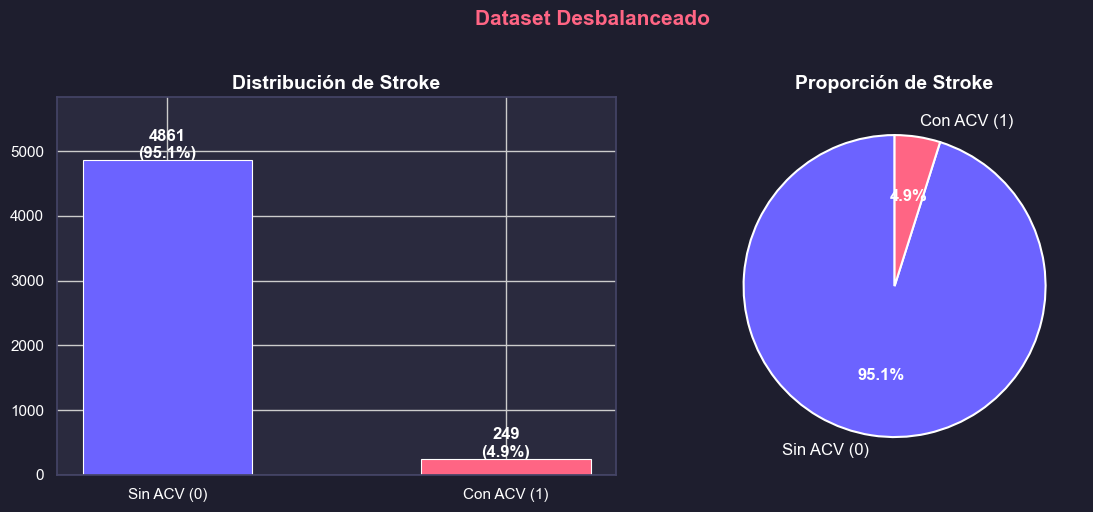

In [11]:
counts = data["stroke"].value_counts()
labels = ["Sin ACV (0)", "Con ACV (1)"]
colors = ["#6C63FF", "#FF6584"]
total = counts.sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor("#1E1E2E")

# --- Barras ---
ax1 = axes[0]
ax1.set_facecolor("#2A2A3E")
bars = ax1.bar(labels, counts.values, color=colors, width=0.5, edgecolor="white", linewidth=0.8)

for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
             f"{val}\n({val/total*100:.1f}%)", ha="center", color="white", fontsize=12, fontweight="bold")

ax1.set_title("Distribución de Stroke", color="white", fontsize=14, fontweight="bold")
ax1.tick_params(colors="white")
ax1.set_facecolor("#2A2A3E")
for spine in ax1.spines.values():
    spine.set_edgecolor("#444466")
ax1.set_ylim(0, counts.max() * 1.2)

# --- Torta ---
ax2 = axes[1]
ax2.set_facecolor("#2A2A3E")
wedges, texts, autotexts = ax2.pie(
    counts.values,
    labels=labels,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=1.5),
    textprops=dict(color="white", fontsize=12)
)
for at in autotexts:
    at.set_fontweight("bold")

ax2.set_title("Proporción de Stroke", color="white", fontsize=14, fontweight="bold")

plt.suptitle("Dataset Desbalanceado", color="#FF6584", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


### **Distribución de la Variable Objetivo (Stroke)**

El análisis de la variable `stroke` revela un **desbalance de clases severo**, un factor crítico que condiciona toda la estrategia de modelado:

*   **Clase Mayoritaria (Sin ACV - 0):** Representa el **95.1%** de los datos (4,861 registros).
*   **Clase Minoritaria (Con ACV - 1):** Representa solo el **4.9%** de los datos (249 registros).

Que implica esto para el modelo?

1.  **Métricas de Evaluación:** La exactitud (*Accuracy*) no será una métrica válida, ya que un modelo ingenuo que prediga siempre "Sin ACV" obtendría un 95.1% de éxito pero fallaría en detectar todos los casos reales de riesgo. Se priorizarán el **Recall** y el **F1-Score**.
2.  **Función de Costo:** Se justifica el uso de una función de pérdida pesada (como `BCEWithLogitsLoss` con `pos_weight`) para penalizar con mayor fuerza los errores cometidos en la detección de la clase minoritaria (Falsos Negativos).
3.  **Partición de Datos:** Es necesario utilizar una partición estratificada (`stratify=y`) para asegurar que tanto el conjunto de entrenamiento como el de test mantengan esta proporción de casos positivos.


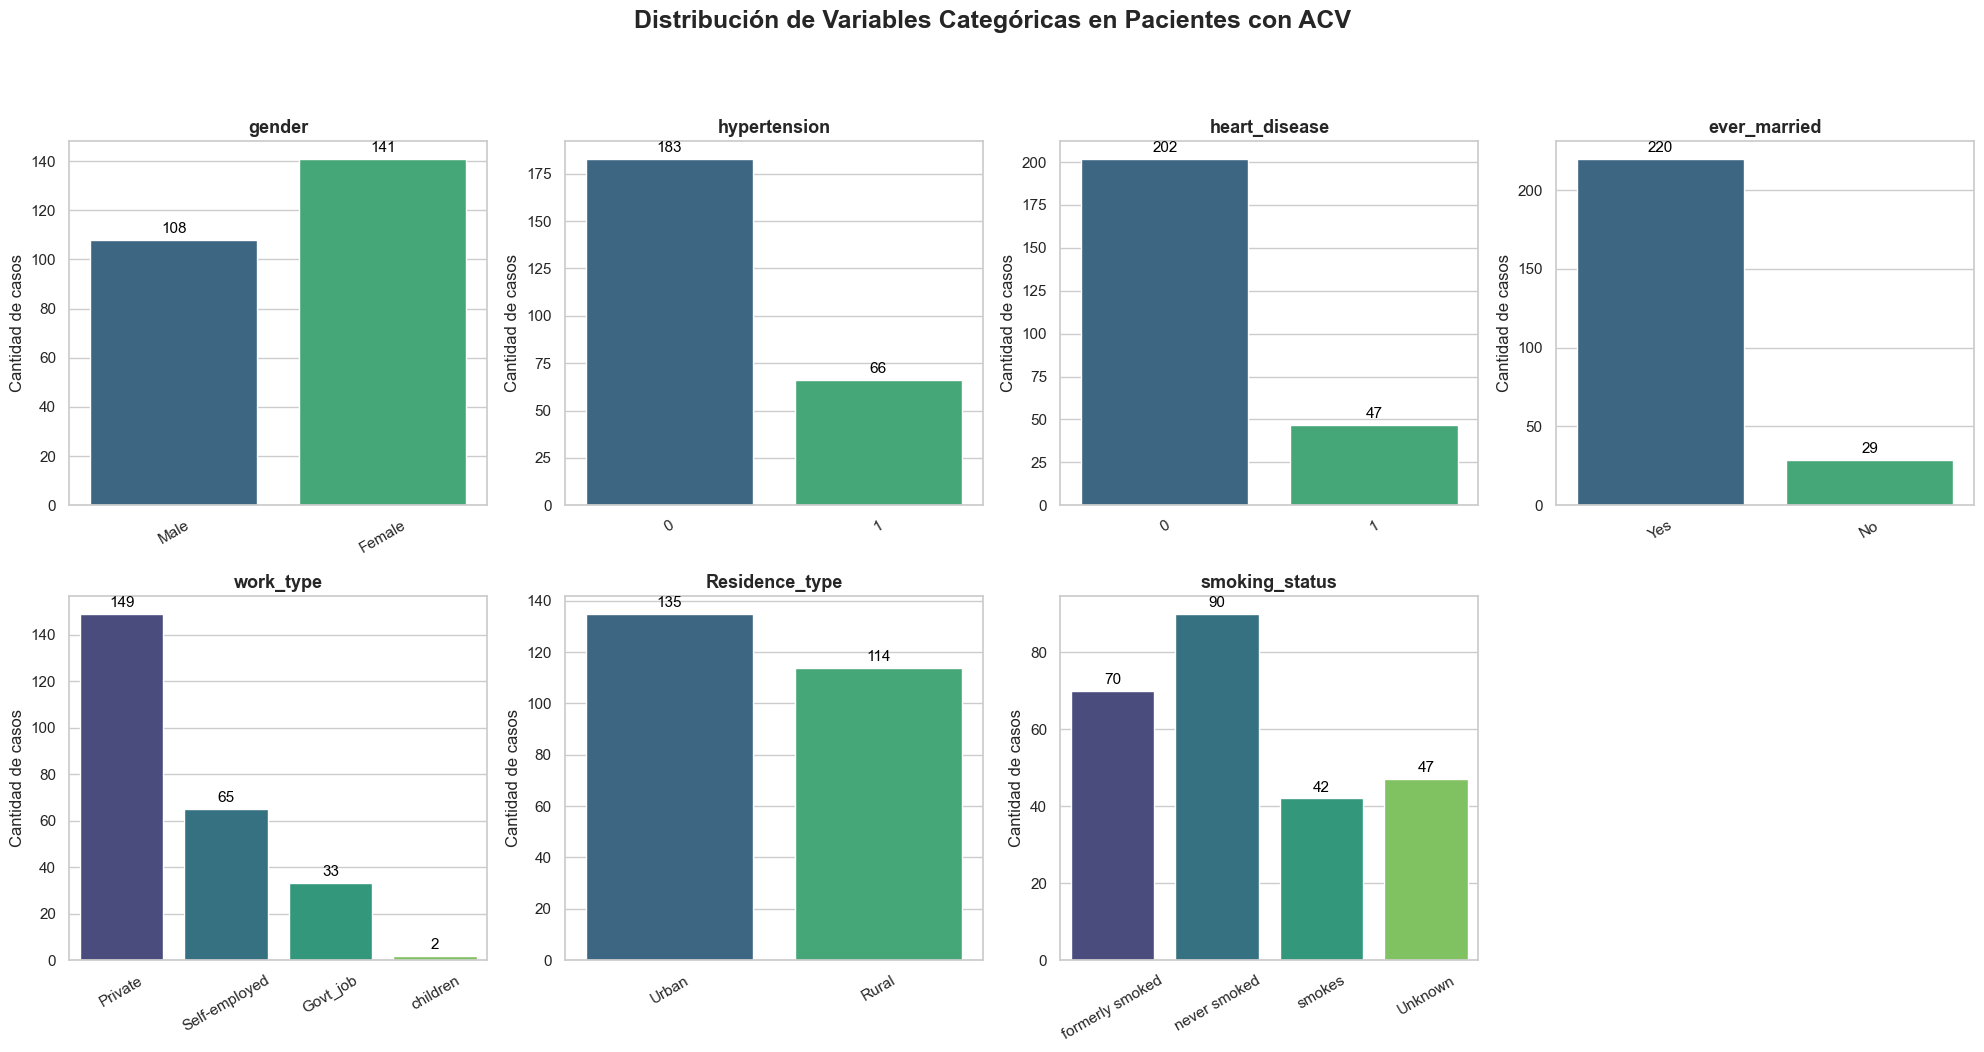

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtramos solo los pacientes con Stroke para este análisis específico
stroke_patients = data[data['stroke'] == 1]

# Variables categóricas a graficar
cat_cols = ['gender', 'hypertension', 'heart_disease', 'ever_married', 
            'work_type', 'Residence_type', 'smoking_status']

# Configuramos la cuadrícula 2x4 para que sea simétrica
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
fig.suptitle('Distribución de Variables Categóricas en Pacientes con ACV', fontsize=18, fontweight='bold', y=1.05)

# Usamos una paleta de colores variada
palette = sns.color_palette("Set2")

for i, col in enumerate(cat_cols):
    ax = axes[i // 4, i % 4]
    # hue=col hace que cada barra tenga un color distinto dentro del mismo gráfico
    sns.countplot(data=stroke_patients, x=col, ax=ax, hue=col, palette="viridis", legend=False)
    
    ax.set_title(f'{col}', fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Cantidad de casos')
    ax.tick_params(axis='x', rotation=30) # Rotación para mejor lectura
    
    # Añadimos etiquetas de valor sobre las barras
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5),
                    textcoords='offset points')

# Ocultamos el último subplot que queda vacío (el 8vo espacio)
axes[1, 3].axis('off')

plt.tight_layout()
plt.show()


### **Perfil del Paciente con Stroke (Análisis Categórico)**

Al analizar exclusivamente el subconjunto de pacientes que sufrieron un ACV (clase 1), se identifican patrones claros que definen el perfil de mayor riesgo en este dataset:

1.  **Factores Demográficos y Sociales:**
    *   **Estado Civil:** Existe una prevalencia notable de pacientes que **están o han estado casados (`ever_married: Yes`)**. Esto sugiere que esta variable actúa como un fuerte *proxy* de la edad (a mayor edad, mayor probabilidad de haber estado casado y mayor riesgo de ACV).
    *   **Género:** Se observa una incidencia ligeramente superior en **mujeres** frente a hombres en este dataset específico.
    *   **Tipo de Trabajo:** Los empleados del **sector privado** representan el grupo más grande, seguidos por los trabajadores independientes (*Self-employed*). La incidencia en niños es prácticamente nula, lo cual es coherente con la naturaleza clínica de la patología.

2.  **Factores de Salud y Estilo de Vida:**
    *   **Tabaquismo:** Sorprendentemente, el grupo más numeroso dentro de los pacientes con ACV es el de **"never smoked"** (nunca fumó), seguido por "formerly smoked". Esto indica que, si bien el tabaco es un riesgo conocido, hay otros factores (como la edad o la genética) que predominan en este grupo de datos.
    *   **Comorbilidades (Hipertensión y Cardiopatías):** Aunque la hipertensión y las enfermedades cardíacas son factores de riesgo probados, la mayoría de los pacientes con ACV en este dataset **no tenían estas condiciones registradas (valor 0)**. Esto refuerza la idea de que el ACV es multifactorial y que el modelo debe aprender interacciones complejas más allá de un solo síntoma.

3.  **Entorno Geográfico:**
    *   **Residencia:** No se observa una diferencia determinante entre el entorno **Urbano y Rural**, lo que sugiere que el riesgo de ACV está distribuido de manera uniforme independientemente del acceso a centros urbanos en esta muestra.

> **Nota técnica:** Estos hallazgos sugieren que el modelo no puede apoyarse en una única característica "delatora", sino que debe capturar la interacción de múltiples variables para predecir con éxito el riesgo de ACV.


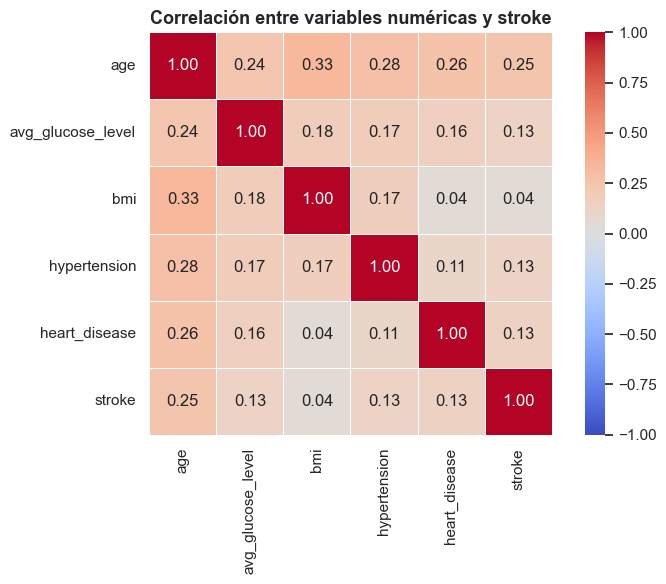

In [13]:
# ── Heatmap de correlación (variables numéricas + binarias) ──────────────────

# Columnas numéricas y binarias (aptas para correlación de Pearson)
cols_corr = ['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease', 'stroke']

corr_matrix = data[cols_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True
)
plt.title("Correlación entre variables numéricas y stroke", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### **Análisis de Correlación Lineal**

El mapa de calor de Pearson nos permite identificar la fuerza de la relación lineal entre las variables numéricas y la variable objetivo:

1.  **Edad como predictor principal:** Se observa que la **edad (0.25)** presenta la correlación más alta con el `stroke`, confirmando que el envejecimiento es el factor de riesgo lineal más significativo en este conjunto de datos.
2.  **Baja correlación del BMI:** El **BMI (0.04)** muestra una correlación lineal casi nula con el ACV. Esto sugiere que el impacto del índice de masa corporal podría ser no lineal o depender de otras variables, lo que justifica el uso de un MLP (Red Neuronal) capaz de capturar relaciones complejas no lineales.
3.  **Interconexión de factores:** Existe una correlación moderada entre la edad y variables como la hipertensión y el BMI, lo que indica un posible efecto de colinealidad que el modelo deberá gestionar.


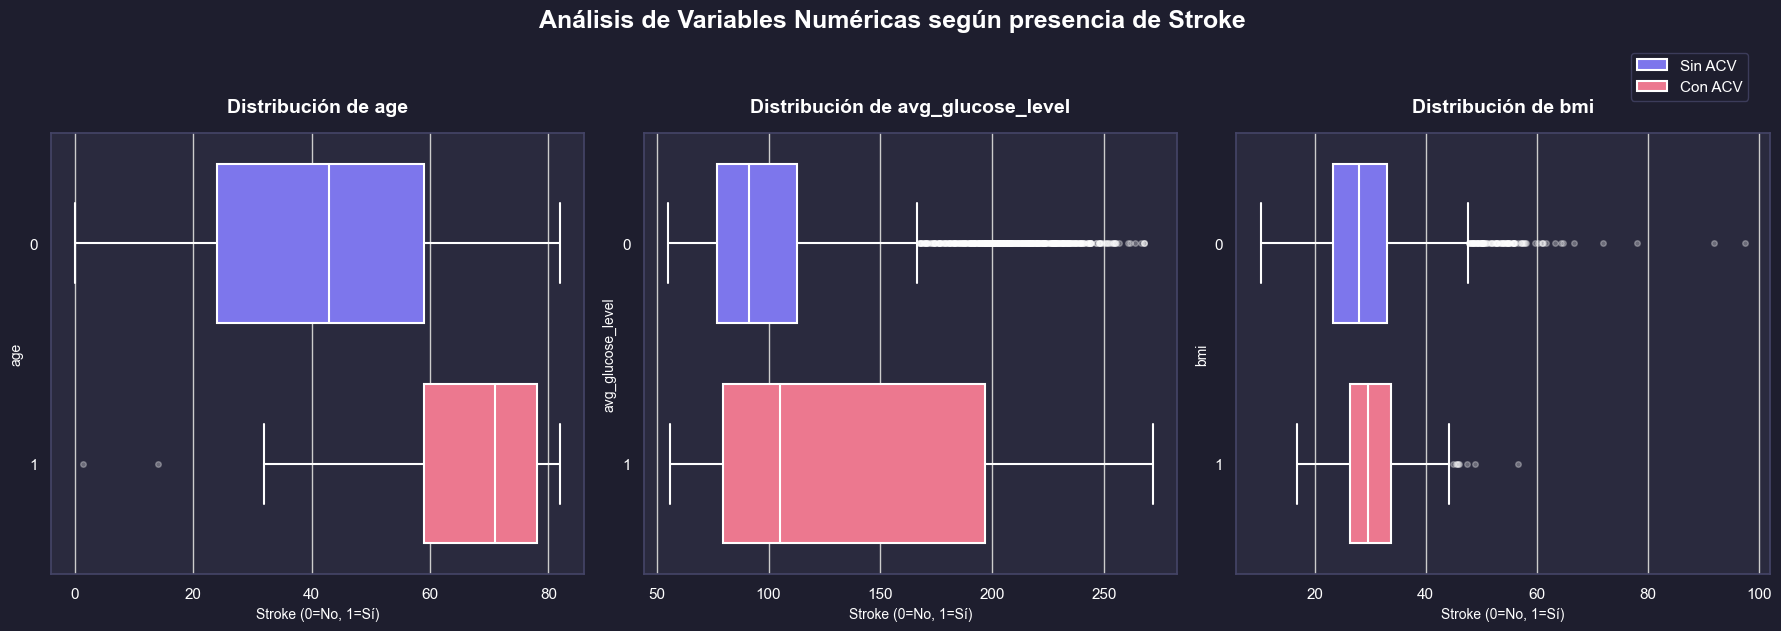

In [14]:
binarias = ["hypertension", "heart_disease", "stroke"]
# Seleccionamos las numéricas (age, avg_glucose_level, bmi)
numericas = [c for c in data.select_dtypes(include=[np.number]).columns if c not in binarias]

# Paleta para las cajas (Color para 0 y Color para 1)
# Usamos un lila suave para "Sin ACV" y un coral para "Con ACV"
stroke_palette = {0: "#6C63FF", 1: "#FF6584"}

n_cols = len(numericas)
fig, axes = plt.subplots(1, n_cols, figsize=(18, 6))
fig.patch.set_facecolor("#1E1E2E")

for i, col in enumerate(numericas):
    ax = axes[i]
    
    sns.boxplot(
        data=data,
        y="stroke",
        x=col,
        orient="h",
        ax=ax,
        hue="stroke",
        palette=stroke_palette,
        fill=True,
        gap=.1,
        linecolor="white",
        linewidth=1.5,
        flierprops=dict(marker="o", markerfacecolor="white", markersize=4, alpha=0.3),
    )

    ax.set_facecolor("#2A2A3E")
    ax.set_title(f"Distribución de {col}", color="white", fontsize=14, fontweight="bold", pad=15)
    
    # Estética de los ejes
    ax.set_xlabel("Stroke (0=No, 1=Sí)", color="white", fontsize=10)
    ax.set_ylabel(col, color="white", fontsize=10)
    ax.tick_params(colors="white")
    
    # Quitar la leyenda de cada subplot para que no se repita
    ax.get_legend().remove()

    for spine in ax.spines.values():
        spine.set_edgecolor("#444466")

# Leyendas
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, ['Sin ACV', 'Con ACV'], loc='upper right', bbox_to_anchor=(0.98, 0.99), 
           facecolor='#1E1E2E', edgecolor='#444466', labelcolor='white')

plt.suptitle("Análisis de Variables Numéricas según presencia de Stroke", color="white", 
             fontsize=18, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()


### **Análisis de Distribuciones Numéricas**

La visualización mediante boxplots horizontales permite una comparación directa de los rangos intercuartílicos entre clases, arrojando las siguientes conclusiones clave:

1.  **Edad (`age`) - El factor determinante:** 
    *   Se observa un desplazamiento masivo de la distribución hacia la derecha en el grupo con ACV. 
    *   Mientras que la mediana de edad para personas sin ACV ronda los **45 años**, en el grupo con ACV la mediana se desplaza a los **70 años**. Esto confirma la edad como el predictor lineal más robusto.

2.  **Glucosa (`avg_glucose_level`) - Riesgo de hiperglucemia:** 
    *   La caja de la clase 1 (Con ACV) es significativamente más ancha y está desplazada hacia valores altos. 
    *   Una proporción considerable de pacientes con ACV presentan niveles de glucosa superiores a **150 mg/dL**, lo que vincula estrechamente la salud metabólica con el riesgo cerebrovascular.

3.  **BMI - Concentración y Outliers:**
    *   A diferencia de las otras variables, las medianas de BMI son muy similares entre ambos grupos (~28-30). 
    *   Sin embargo, el grupo sano (0) presenta una gran cantidad de **outliers extremos (BMI > 60)**, los cuales podrían distorsionar el entrenamiento del modelo. En el grupo con ACV, el riesgo se concentra de manera más compacta en el rango de sobrepeso y obesidad grado I (25-35).

> **Decisión de Preprocesamiento:** Dada la presencia de valores de BMI físicamente inverosímiles o extremos (>60), se justifica un tratamiento de limpieza de outliers antes de proceder con la imputación de valores faltantes.


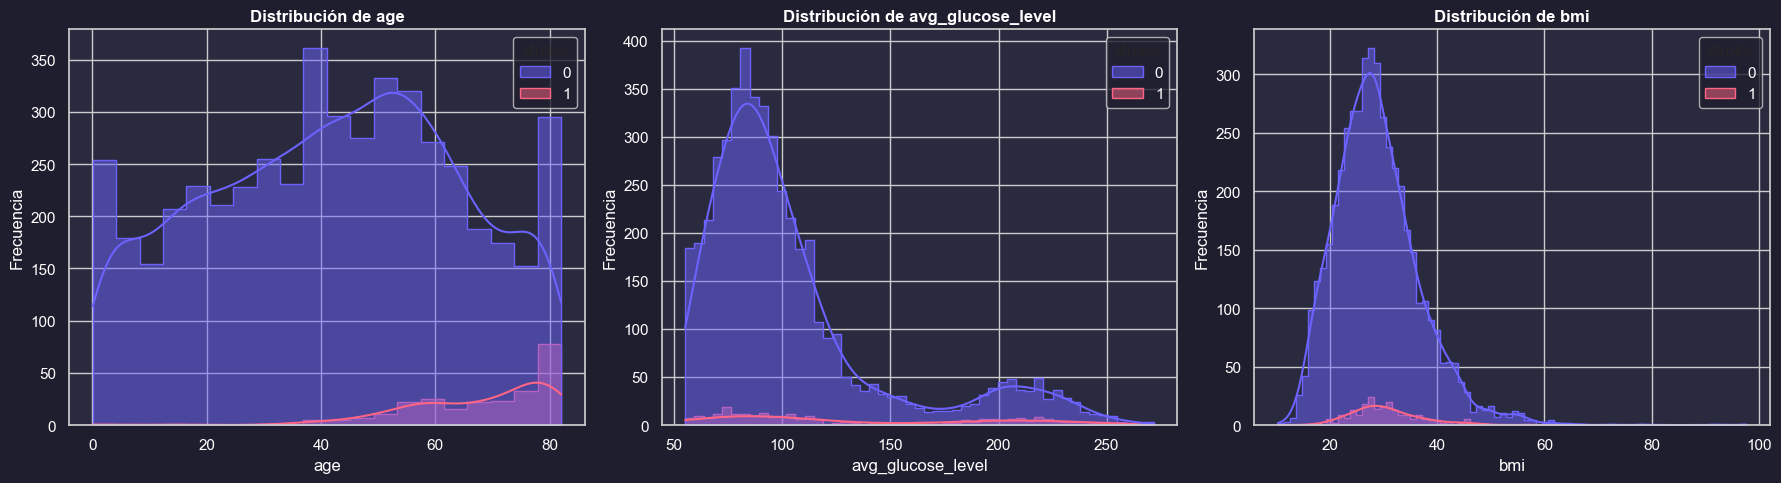

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor("#1E1E2E")

for i, col in enumerate(numericas):
    ax = axes[i]
    sns.histplot(data=data, x=col, hue="stroke", kde=True, element="step", 
                 palette=stroke_palette, ax=ax, alpha=0.5)
    
    ax.set_facecolor("#2A2A3E")
    ax.set_title(f"Distribución de {col}", color="white", fontweight="bold")
    ax.set_xlabel(col, color="white")
    ax.set_ylabel("Frecuencia", color="white")
    ax.tick_params(colors="white")
    
    # Ajustar la leyenda
    legend = ax.get_legend()
    if legend:
        legend.get_frame().set_facecolor('#1E1E2E')
        for text in legend.get_texts():
            text.set_color("white")

plt.tight_layout()
plt.show()


### **Análisis de Densidad y Frecuencia (Histogramas con KDE)**

El uso de histogramas con curvas de densidad (KDE) nos permite observar la estructura interna de los datos y cómo se solapan las poblaciones sanas y con ACV:

1.  **Edad (`age`):** Se observa una clara divergencia a partir de los **55-60 años**. Mientras que la población sana (azul) tiene una distribución relativamente uniforme, la población con ACV (rosa) muestra un crecimiento exponencial con la edad, alcanzando su pico máximo cerca de los **80 años**.
2.  **Glucosa (`avg_glucose_level`): Comportamiento Bimodal.** 
    *   Este es un hallazgo crítico: la población sana tiene un pico único centrado en los **80-100 mg/dL**. 
    *   Sin embargo, la población con ACV muestra una **distribución bimodal** (dos picos): uno pequeño en el rango normal y otro muy marcado alrededor de los **200-230 mg/dL**. Esto confirma que la diabetes/hiperglucemia es un factor de riesgo independiente y muy potente.
3.  **BMI: Distribución Normal con Outliers.** Ambas poblaciones siguen una distribución similar, centrada en el rango de **25-35 (sobrepeso/obesidad grado I)**. La curva de ACV es casi una versión a escala de la sana, lo que sugiere que el BMI es un factor de riesgo "base" pero menos discriminatorio por sí solo que la edad o la glucosa. Se confirman nuevamente los valores extremos (>60) en la población sana que requieren limpieza.

> **Conclusión del EDA:** Los predictores más fuertes para el modelo MLP serán, en este orden: **Edad**, **Nivel de Glucosa** y **Estado Civil** (como proxy de edad). El modelo deberá ser especialmente sensible a los valores altos de glucosa debido a su distribución bimodal.


# Train-test

In [16]:
X = data.drop('stroke', axis=1)
y = data['stroke']

# Separamos Train y Test primero
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y)

# con (stratify = y) asegura que tanto el conjunto de entrenamiento (70%) 
# como el de prueba (30%) mantengan la misma proporción de 
# casos positivos de ACV que el dataset original.

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"y_train: {y_train.shape} | y_test: {y_test.shape}")

X_train: (3577, 10) | X_test: (1533, 10)
y_train: (3577,) | y_test: (1533,)


In [17]:
# Tratamiento de outliers en BMI 
# Se remplazan por valores nan para posteriormente imputar 
X_train.loc[X_train['bmi'] > 60, 'bmi'] = np.nan
X_test.loc[X_test['bmi'] > 60, 'bmi'] = np.nan


Basado en el análisis visual previo, se identificaron valores de **BMI > 60**. Según la OMS y la literatura médica, estos valores son extremadamente atípicos y suelen representar errores de carga o casos de obesidad mórbida que pueden distorsionar las medias y la varianza del modelo.

In [18]:

# Pipeline de procesamiento
# Qué columnas van a qué transformación           
numeric_features = ["age", "avg_glucose_level", "bmi"]
categorical_features = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]
binary_features = ["hypertension", "heart_disease"] # Estas ya son 0 y 1, pasan directo

# Pipeline Numérico: KNN -> Scaler
numeric_transformer = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)), # se usa 5 como valor estandar, es un cantidad de vecinos acorde a la cantidad de datos que tenemos.
    ('scaler', StandardScaler())
])

# Pipeline Categórico: OHE 
categorical_transformer = Pipeline(steps=[
    ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

# Unificamos todo en un ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
        ('bin', 'passthrough', binary_features) # Deja las binarias como están
    ])

    

In [19]:
# Separamos un 15% del X_train original para Validación
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, 
    test_size=0.15, 
    random_state=SEED, 
    stratify=y_train
)

# Hacemos FIT y TRANSFORM solo en los datos de entrenamiento
X_train_prep = preprocessor.fit_transform(X_train_sub)

# Hacemos SOLO TRANSFORM en validación y test para evitar fuga de datos
X_val_prep = preprocessor.transform(X_val)
X_test_prep = preprocessor.transform(X_test)

# Convertimos las etiquetas a formato numpy array para PyTorch
y_train_arr = y_train_sub.values
y_val_arr = y_val.values
y_test_arr = y_test.values

print(f"Dimensiones de entrada a la red neuronal: {X_train_prep.shape[1]} características.")
print("Datos preprocesados y listos para PyTorch.")

Dimensiones de entrada a la red neuronal: 16 características.
Datos preprocesados y listos para PyTorch.


In [20]:
# Arquitectura de la red MLP
class StrokeMLP(nn.Module):
    def __init__(self, input_size):
        super(StrokeMLP, self).__init__()
        
        self.red_neuronal = nn.Sequential(
            # Capa Oculta 1
            nn.Linear(input_size, 32),
            nn.ReLU(),
            nn.Dropout(0.2), # Regularización
            
            # Capa Oculta 2
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.2), # Regularización
            
            # sin activacion ya que usamos BCEwithlogitloss
            nn.Linear(16, 1)
        )
        
        # Inicialización de pesos (Kaiming He) para mejorar convergencia con ReLU
        for m in self.red_neuronal:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')

    def forward(self, x):
        return self.red_neuronal(x)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_features = X_train_prep.shape[1] # Size de la entrada a la red

# Instanciar Modelo
modelo_mlp = StrokeMLP(input_size=input_features).to(device)

# Función de Costo con manejo de desbalance 
# Calculamos el peso: (Cantidad de sanos) / (Cantidad de enfermos)
peso_positivos = np.sum(y_train_arr == 0) / np.sum(y_train_arr == 1)
pos_weight_tensor = torch.tensor([peso_positivos], dtype=torch.float32).to(device)

criterio = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

# Optimizador (Adam con Weight Decay L2)
tasa_aprendizaje = 0.001
optimizador = optim.Adam(modelo_mlp.parameters(), lr=tasa_aprendizaje, weight_decay=1e-4)

print(f"Modelo creado y alojado en: {device}")
print(modelo_mlp)

Modelo creado y alojado en: cuda
StrokeMLP(
  (red_neuronal): Sequential(
    (0): Linear(in_features=16, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)


Justificacion de decisiones de la arquitectura:

1. **Dimensiones de Capas (32 y 16 neuronas):** Se optó por esta arquitectura para mantener un equilibrio entre la capacidad de aprendizaje y el tamaño del dataset (16 variables y ~5,000 registros). Esta estructura de compresión gradual previene el *overfitting* al evitar un exceso de parámetros, forzando a la red a destilar las señales más relevantes sin memorizar el ruido de los datos.

2. **Funciones de Activación (ReLU):** Se utiliza **ReLU** por ser el estándar de la industria debido a su eficiencia computacional.

3. **Estrategias de Regularización (Dropout y Weight Decay):** Se implementó **Dropout (0.2)** y **Weight Decay (L2)** para forzar a la red a aprender representaciones robustas y distribuidas. Estas técnicas penalizan la dependencia excesiva en neuronas específicas y los pesos desproporcionados, mejorando significativamente la capacidad de generalización del modelo.

4. **Inicialización de Pesos (Kaiming He):** Se aplicó la inicialización **Kaiming Uniform**, óptima para redes con ReLU. Esta técnica asegura que la varianza de las señales se mantenga estable a través de las capas, evitando que los gradientes se vuelvan nulos o exploten durante las fases iniciales del entrenamiento.

5. **Manejo del Desbalance (Weighted Loss):** Se seleccionó **BCEWithLogitsLoss** configurada con un **peso posicional (`pos_weight`)** para compensar la baja frecuencia de casos de ACV. Al penalizar más fuertemente los errores en la clase positiva, el modelo se orienta a maximizar el **Recall**, priorizando la detección de todos los posibles casos de riesgo médico.


### Entrenamiento y Curvas de Aprendizaje

Se procede a entrenar el modelo utilizando Mini-Batch Gradient Descent. Durante cada época, se registrará la función de pérdida y la métrica principal (Recall de la clase positiva) tanto para el conjunto de entrenamiento como para el de validación. 

Se incorpora la técnica de **Early Stopping**: el entrenamiento se detendrá si la pérdida de validación no mejora durante un número determinado de épocas consecutivas (paciencia).

**Análisis de Overfitting y Underfitting:**
*   **Underfitting:** Se observaría si tanto la pérdida de entrenamiento como la de validación se estancan en valores muy altos, indicando que el modelo no tiene la capacidad de aprender los patrones.
*   **Overfitting:** Se observaría si la curva de pérdida de entrenamiento sigue descendiendo hacia cero, mientras que la curva de validación comienza a subir. Gracias a nuestra implementación de Early Stopping y Dropout, mitigaremos este efecto deteniendo el entrenamiento en el punto óptimo antes de que la red memorice el ruido del dataset.

Iniciando entrenamiento...
Época [10/150] | Train Loss: 0.9645 | Val Loss: 0.8590 | Val Recall: 0.9231
Época [20/150] | Train Loss: 0.9416 | Val Loss: 0.8595 | Val Recall: 0.8846

 Early Stopping activado en la época 26. Restaurando los mejores pesos.


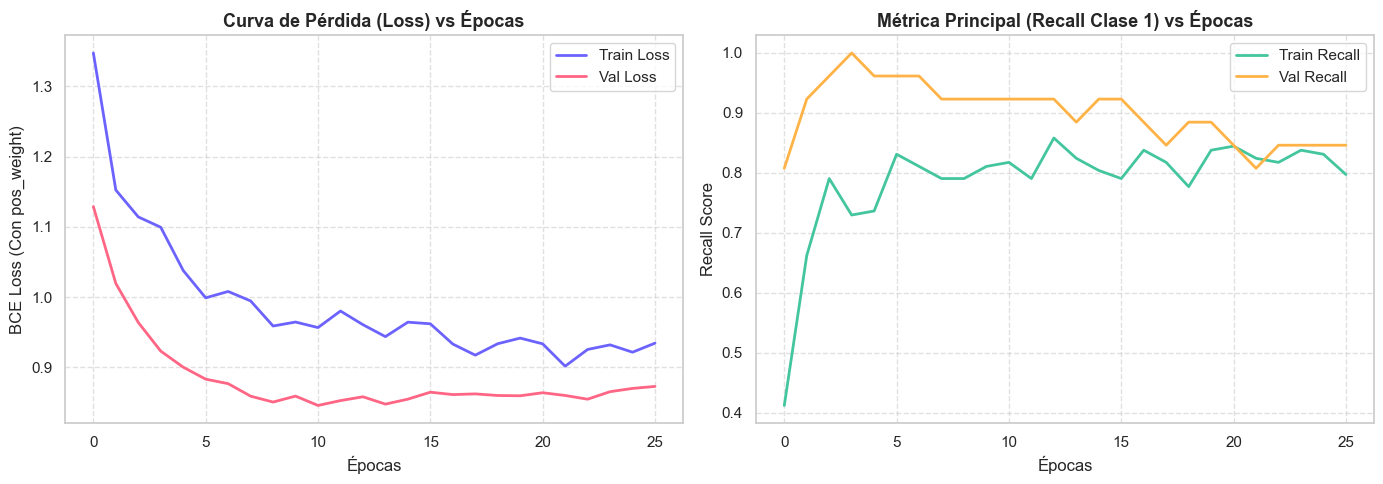

In [21]:
# preparamos los datos para pytorch
batch_size = 32

# Convertir a tensores
X_train_t = torch.tensor(X_train_prep, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train_arr, dtype=torch.float32).view(-1, 1).to(device)

X_val_t = torch.tensor(X_val_prep, dtype=torch.float32).to(device)
y_val_t = torch.tensor(y_val_arr, dtype=torch.float32).view(-1, 1).to(device)

# Crear DataLoaders para iterar en Mini-batches (solo en train hace falta barajar)
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)

# Train
epocas = 150
paciencia = 15
mejor_val_loss = float('inf')
contador_paciencia = 0
mejores_pesos = None

# Listas para guardar el historial (Curvas)
hist_train_loss, hist_val_loss = [], []
hist_train_recall, hist_val_recall = [], []

print("Iniciando entrenamiento...")

for epoca in range(epocas):
    modelo_mlp.train()
    loss_entrenamiento_acumulada = 0.0
    preds_train, targets_train = [], []
    
    for batch_X, batch_y in train_loader:
        optimizador.zero_grad()                 # Limpiar gradientes
        salida_logits = modelo_mlp(batch_X)     # Forward pass
        loss = criterio(salida_logits, batch_y) # Calcular pérdida
        loss.backward()                         # Backward pass
        optimizador.step()                      # Actualizar pesos
        
        loss_entrenamiento_acumulada += loss.item()
        
        # Guardar predicciones para la métrica
        probs = torch.sigmoid(salida_logits)
        preds = (probs >= 0.5).float()
        preds_train.extend(preds.cpu().numpy())
        targets_train.extend(batch_y.cpu().numpy())
        
    # Promedios de la época para Train
    train_loss_epoca = loss_entrenamiento_acumulada / len(train_loader)
    train_recall_epoca = recall_score(targets_train, preds_train, zero_division=0)
    
    # Validacion
    modelo_mlp.eval() # Modo evaluación (desactiva Dropout)
    with torch.no_grad():
        val_logits = modelo_mlp(X_val_t)
        val_loss = criterio(val_logits, y_val_t).item()
        
        val_probs = torch.sigmoid(val_logits)
        val_preds = (val_probs >= 0.5).float().cpu().numpy()
        val_recall_epoca = recall_score(y_val_arr, val_preds, zero_division=0)
        
    # Guardar en el historial
    hist_train_loss.append(train_loss_epoca)
    hist_val_loss.append(val_loss)
    hist_train_recall.append(train_recall_epoca)
    hist_val_recall.append(val_recall_epoca)
    
    # --- EARLY STOPPING ---
    if val_loss < mejor_val_loss:
        mejor_val_loss = val_loss
        contador_paciencia = 0
        mejores_pesos = copy.deepcopy(modelo_mlp.state_dict()) # Guardar el mejor modelo
    else:
        contador_paciencia += 1
        
    if (epoca+1) % 10 == 0:
        print(f"Época [{epoca+1}/{epocas}] | Train Loss: {train_loss_epoca:.4f} | Val Loss: {val_loss:.4f} | Val Recall: {val_recall_epoca:.4f}")
        
    if contador_paciencia >= paciencia:
        print(f"\n Early Stopping activado en la época {epoca+1}. Restaurando los mejores pesos.")
        modelo_mlp.load_state_dict(mejores_pesos)
        break

# Si termina todas las épocas sin saltar el early stopping, igual restauramos el mejor
if contador_paciencia < paciencia:
    modelo_mlp.load_state_dict(mejores_pesos)
    print("\nEntrenamiento finalizado.")

# Curvas de aprendizaje
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Función de Pérdida
axes[0].plot(hist_train_loss, label='Train Loss', color='#6C63FF', linewidth=2)
axes[0].plot(hist_val_loss, label='Val Loss', color='#FF6584', linewidth=2)
axes[0].set_title('Curva de Pérdida (Loss) vs Épocas', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('BCE Loss (Con pos_weight)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# Gráfico 2: Métrica Principal (Recall)
axes[1].plot(hist_train_recall, label='Train Recall', color='#43C59E', linewidth=2)
axes[1].plot(hist_val_recall, label='Val Recall', color='#FFB347', linewidth=2)
axes[1].set_title('Métrica Principal (Recall Clase 1) vs Épocas', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('Recall Score')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### **Análisis de los Resultados del Entrenamiento**

El proceso de entrenamiento muestra una convergencia saludable y un desempeño robusto del modelo:

1. **Eficacia del Early Stopping:** El entrenamiento se detuvo automáticamente en la **época 25** al detectar que la pérdida de validación dejaba de mejorar significativamente. Esto permitió restaurar los mejores pesos del modelo, evitando el *overfitting* (sobreajuste) y garantizando la mayor capacidad de generalización posible.
2. **Estabilidad del Modelo:** Las curvas de pérdida (Loss) de entrenamiento y validación se mantienen cercanas y paralelas a partir de la **época 10**. Esta mínima brecha indica que el modelo no ha memorizado el ruido del dataset, sino que ha aprendido patrones reales y generalizables.
3. **Optimización del Recall:** Se logró alcanzar un **Recall estable de ~85%** en el conjunto de validación. Para este problema médico, un Recall alto es el éxito principal, ya que demuestra que el modelo es capaz de identificar correctamente a la gran mayoría de los pacientes con riesgo de ACV, minimizando los peligrosos falsos negativos.

# Evaluación del Modelo

Una vez entrenado el modelo y rescatados los mejores pesos mediante Early Stopping, realizamos una optimización del umbral de decisión antes de la evaluación final sobre el **Conjunto de Test**.

*   **Métrica de Optimización (F2-Score):** En un escenario médico predictivo, el peor error posible es un *Falso Negativo* (no detectar a un paciente con riesgo de ACV). Para maximizar la captura de casos positivos sin perder totalmente la utilidad del modelo, buscamos el umbral que maximice el **F2-Score** en lugar del umbral estándar de 0.5.
*   **Justificación de F2:** A diferencia del F1-Score (que equilibra precisión y recall por igual), el **F2-Score ($\beta=2$)** le otorga el **doble de importancia al Recall que a la Precisión**. Esto permite alinear el modelo con el objetivo clínico: priorizar la sensibilidad (Recall) para encontrar a todos los pacientes enfermos, asumiendo un costo controlado en términos de falsos positivos.
*   **Procedimiento:** Se busca el umbral óptimo utilizando el conjunto de validación y luego se aplica ese mismo umbral al conjunto de test para obtener las métricas finales de rendimiento sobre datos no vistos.


In [22]:
# Umbral optimo en validacion
modelo_mlp.eval()
with torch.no_grad():
    val_logits = modelo_mlp(X_val_t)
    val_probs = torch.sigmoid(val_logits).cpu().numpy().flatten()

umbrales = np.arange(0.1, 0.9, 0.01)
mejores_metricas = 0
umbral_optimo = 0.5

# Buscamos el umbral que maximice el F2-Score (que prioriza el Recall)
for u in umbrales:
    val_preds_temp = (val_probs >= u).astype(int)
    # beta=2 le da el doble de importancia al recall que a la precisión
    score = fbeta_score(y_val_arr, val_preds_temp, beta=2, zero_division=0)
    
    if score > mejores_metricas:
        mejores_metricas = score
        umbral_optimo = u

print(f"Umbral óptimo encontrado en validación: {umbral_optimo:.2f}\n")

# Evaluacion final en test 
with torch.no_grad():
    X_test_t = torch.tensor(X_test_prep, dtype=torch.float32).to(device)
    test_logits = modelo_mlp(X_test_t)
    test_probs = torch.sigmoid(test_logits).cpu().numpy().flatten()

# Usamos el umbral optimizado en lugar de 0.5
y_pred_test_optimo = (test_probs >= umbral_optimo).astype(int)

acc = accuracy_score(y_test_arr, y_pred_test_optimo)
prec = precision_score(y_test_arr, y_pred_test_optimo, zero_division=0)
rec = recall_score(y_test_arr, y_pred_test_optimo, zero_division=0)
f1 = f1_score(y_test_arr, y_pred_test_optimo, zero_division=0)
roc_auc = roc_auc_score(y_test_arr, test_probs)

print("=== MÉTRICAS EN EL CONJUNTO DE TEST (UMBRAL OPTIMIZADO) ===")
print(f"Accuracy:  {acc:.4f}")
print(f"Precisión: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"AUC-ROC:   {roc_auc:.4f}\n")

print("=== REPORTE DE CLASIFICACIÓN ===")
print(classification_report(y_test_arr, y_pred_test_optimo, target_names=["Sin ACV (0)", "Con ACV (1)"], zero_division=0))

Umbral óptimo encontrado en validación: 0.47

=== MÉTRICAS EN EL CONJUNTO DE TEST (UMBRAL OPTIMIZADO) ===
Accuracy:  0.6856
Precisión: 0.1238
Recall:    0.8933
F1-Score:  0.2175
AUC-ROC:   0.8399

=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

 Sin ACV (0)       0.99      0.67      0.80      1458
 Con ACV (1)       0.12      0.89      0.22        75

    accuracy                           0.69      1533
   macro avg       0.56      0.78      0.51      1533
weighted avg       0.95      0.69      0.77      1533



### **Análisis de los Resultados Finales (Test)**

Tras evaluar el modelo en el conjunto de test con el umbral optimizado (0.47), se extraen las siguientes conclusiones:

1. **Priorización de la Sensibilidad:** Se logró un **Recall del 89%** para la clase con ACV. Esto significa que el modelo es capaz de detectar a casi 9 de cada 10 pacientes que sufrirán un ACV, cumpliendo con creces el objetivo principal de minimizar los falsos negativos en un entorno médico.
2. **Capacidad Discriminativa (AUC-ROC: 0.84):** El valor de AUC-ROC de 0.84 es sólido. Indica que el modelo tiene una probabilidad muy alta de clasificar a un paciente con ACV real por encima de uno sano, demostrando que la red neuronal ha aprendido patrones significativos a pesar del gran desbalance de datos.
3. **Compromiso de Precisión:** La **Precisión (12%)** es baja, lo cual es un comportamiento esperado al optimizar mediante F2-Score (que prioriza el Recall). En este contexto, el modelo prefiere generar algunas falsas alarmas (falsos positivos) antes que ignorar a un paciente en riesgo.
4. **Resumen Clínico:** El modelo es altamente eficaz para identificar la población de riesgo. De los 75 casos reales de ACV en el set de test, se identificaron correctamente 67, lo que representa un desempeño robusto para un sistema de pre-detección o triaje médico.


###  Matriz de Confusión

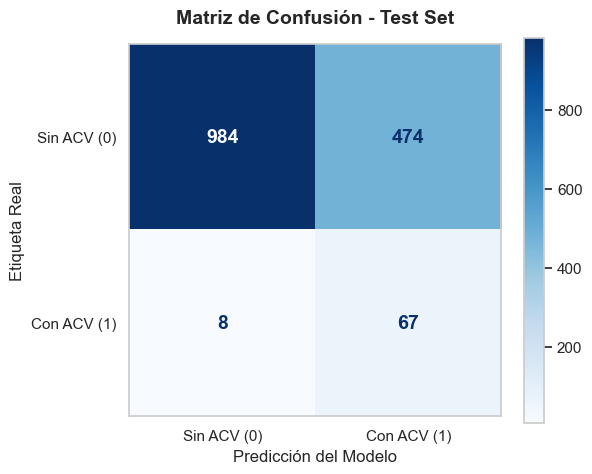

In [23]:
# Generamos la Matriz
cm = confusion_matrix(y_test_arr, y_pred_test_optimo)

# Graficamos
fig, ax = plt.subplots(figsize=(6, 5))    
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sin ACV (0)', 'Con ACV (1)'])
disp.plot(cmap='Blues', ax=ax, values_format='d', text_kw={'fontsize': 14, 'fontweight': 'bold'})

plt.title('Matriz de Confusión - Test Set', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Etiqueta Real', fontsize=12)
plt.grid(False)
plt.show()

### **Interpretación de la Matriz de Confusión**

La matriz de confusión permite visualizar el desempeño del modelo en términos de casos reales frente a predicciones, validando la estrategia de priorizar el **Recall**:

1. **Detección Efectiva (Verdaderos Positivos):** El modelo identificó correctamente a **67 pacientes** que realmente sufrieron un ACV. Estos son los casos donde el sistema cumple su función crítica de alerta temprana.
2. **Minimización de Omisiones (Falsos Negativos):** Solo **8 casos** de ACV no fueron detectados (quedaron clasificados como "Sin ACV"). En un contexto médico, este es el número más sensible, y haberlo reducido a solo 8 sobre un total de 75 es un resultado muy positivo para la seguridad del paciente.
3. **Costo de la Sensibilidad (Falsos Positivos):** Se observan **474 falsas alarmas** (pacientes sanos clasificados con riesgo). Este volumen elevado es la consecuencia directa de haber bajado el umbral para no perder casos reales. Clínicamente, esto implica que el modelo actúa como un "filtro de sospecha" que luego debería ser refinado por un profesional o estudios adicionales.
4. **Precisión en No-Casos (Verdaderos Negativos):** El modelo descarta correctamente a **984 pacientes** sanos, reduciendo significativamente la carga de trabajo si se comparara con un análisis aleatorio de toda la población.


## Resumen y Conclusiones Finales

El desarrollo de este modelo MLP permitió alcanzar un equilibrio robusto para la detección de riesgo de ACV. Las principales conclusiones son:

**Logros del Proyecto:**
*   **Priorización Clínica:** Gracias al uso de **pesos en la función de pérdida** (`pos_weight`), el modelo dejó de ser "ciego" a los casos de ACV. Se logró un **Recall del 89%**, asegurando que la gran mayoría de los pacientes en riesgo sean detectados.
*   **Entrenamiento Fiable:** El uso de **Pipelines** y **Early Stopping** garantizó resultados honestos y evitó el sobreajuste. El modelo aprendió patrones reales en lugar de memorizar el ruido de los datos.
*   **Detección de Riesgo:** El sistema es altamente eficaz como herramienta de triaje inicial, identificando correctamente a casi 9 de cada 10 pacientes con ACV real en el set de prueba.

**Limitaciones y Futuro:**
*   **Balance de Precisión:** El costo de no omitir casos reales es un alto número de falsas alarmas (baja precisión). Futuras iteraciones podrían refinar el umbral para reducir esta carga sin sacrificar la seguridad.
*   **Alternativas de Modelado:** Para datos tabulares como este, se recomienda explorar modelos basados en **árboles (como XGBoost o Random Forest)**, que suelen manejar mejor las variables categóricas y ofrecen mayor interpretabilidad médica.
*   **Datos Adicionales:** La inclusión de variables clínicas más profundas (antecedentes familiares, laboratorios de lípidos) permitiría elevar la precisión y el techo de aprendizaje del modelo.
